a) Dimensión del espacio de Hilbert

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import time
from scipy.linalg import expm, eigh
from itertools import product

def hilbert_dim(N):
    return 2**N

# Demostración para algunos N
for N in range(1, 9):
    print(f"N = {N} → dim = {hilbert_dim(N)} (2^{N})")

N = 1 → dim = 2 (2^1)
N = 2 → dim = 4 (2^2)
N = 3 → dim = 8 (2^3)
N = 4 → dim = 16 (2^4)
N = 5 → dim = 32 (2^5)
N = 6 → dim = 64 (2^6)
N = 7 → dim = 128 (2^7)
N = 8 → dim = 256 (2^8)


b) Construcción del Hamiltoniano

In [7]:
# Matrices de Pauli 
sigma_x = np.array([[0, 1], [1, 0]], dtype=complex)
sigma_y = np.array([[0, -1j], [1j, 0]], dtype=complex)
sigma_z = np.array([[1, 0], [0, -1]], dtype=complex)
identity = np.eye(2, dtype=complex)

def kron_n(matrices):
    """Compute Kronecker product of a list of matrices."""
    result = matrices[0]
    for mat in matrices[1:]:
        result = np.kron(result, mat)
    return result

def operator_on_site(operator, site, N):
    """Build operator acting on a given site (0-indexed) as a tensor product."""
    matrices = [identity] * N
    matrices[site] = operator
    return kron_n(matrices)

def build_ising_hamiltonian(N, J, B):
    """
    Construct the transverse Ising Hamiltonian matrix.
    H = J * sum_{i=0}^{N-2} σ_x(i) σ_x(i+1) + B * sum_{i=0}^{N-1} σ_z(i)
    """
    dim = hilbert_dim(N)
    H = np.zeros((dim, dim), dtype=complex)
    
    # Término iterativo: J * σ_x(i) ⊗ σ_x(i+1)
    for i in range(N-1):
        # Crea σ_x(i) σ_x(i+1) como un producto de operadores
        matrices = [identity] * N
        matrices[i] = sigma_x
        matrices[i+1] = sigma_x
        op_xx = kron_n(matrices)
        H += J * op_xx
    
    # Término: B * σ_z(i)
    for i in range(N):
        op_z = operator_on_site(sigma_z, i, N)
        H += B * op_z
    
    return H

# Check para N=2
N_test = 2
J_test, B_test = 1.0, 0.5
H_test = build_ising_hamiltonian(N_test, J_test, B_test)
print(f"Prueba para N={N_test}, J={J_test}, B={B_test}:")
print("Forma:", H_test.shape)
print("Verificación hermítica: máxima diferencia =", np.max(np.abs(H_test - H_test.conj().T)))
# Valores propios (deberían ser reales)
eigvals = np.linalg.eigvalsh(H_test)
print("Valores propios (reales):", eigvals)

Prueba para N=2, J=1.0, B=0.5:
Forma: (4, 4)
Verificación hermítica: máxima diferencia = 0.0
Valores propios (reales): [-1.41421356 -1.          1.          1.41421356]


c) Diagonalización, operadores y probabilidad del estado inicial

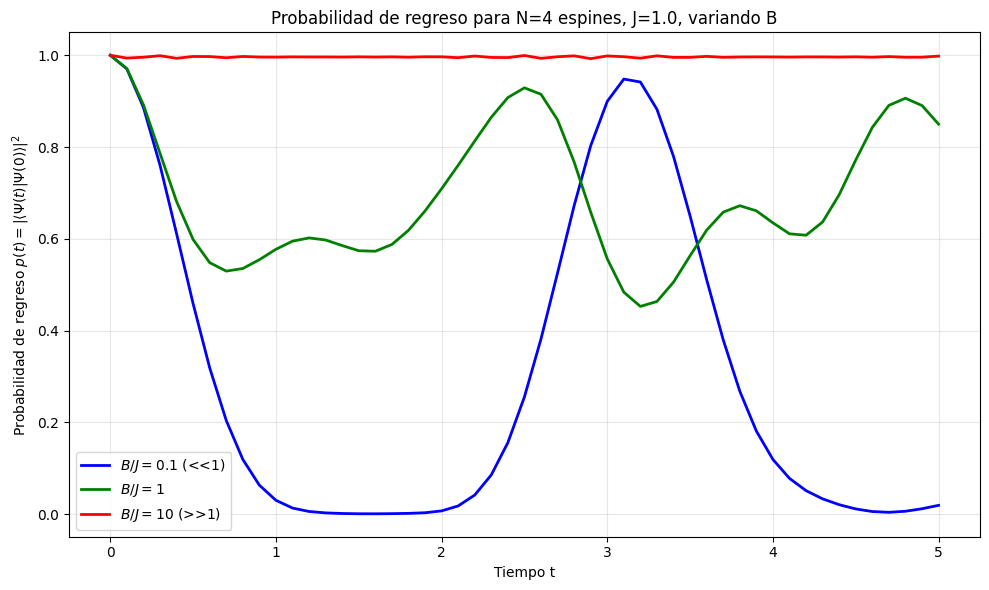

In [8]:
def all_down_state(N):
    """Return the state |↓↓...↓> as a vector in the computational basis."""
    dim = hilbert_dim(N)
    state = np.zeros(dim, dtype=complex)
    state[-1] = 1.0   # because all down corresponds to binary number 111...1 (N ones)
    return state

def evolve_state_using_diag(H, psi0, times):
    """
    Evolve the state by diagonalizing H once.
    Returns array of states at each time.
    """
    eigvals, eigvecs = eigh(H)
    # Estado inicial
    c0 = eigvecs.conj().T @ psi0
    states = []
    for t in times:
        c = c0 * np.exp(-1j * eigvals * t)
        psi = eigvecs @ c
        states.append(psi)
    return np.array(states)

# Parametros para la simulación
N_evo = 4
J_fixed = 1.0
dt = 0.1
t_max = 5.0
times = np.arange(0, t_max + dt/2, dt)

# Regimenes: B << J, B = J, B >> J
B_values = [0.1, 1.0, 10.0]
labels = [r'$B/J = 0.1$ (<<1)', r'$B/J = 1$', r'$B/J = 10$ (>>1)']
colors = ['blue', 'green', 'red']

plt.figure(figsize=(10, 6))

for B, label, color in zip(B_values, labels, colors):
    H = build_ising_hamiltonian(N_evo, J_fixed, B)
    psi0 = all_down_state(N_evo)
    states = evolve_state_using_diag(H, psi0, times)
    overlaps = np.abs(np.dot(psi0.conj(), states.T))**2
    plt.plot(times, overlaps, color=color, label=label, linewidth=2)

plt.xlabel('Tiempo t')
plt.ylabel(r'Probabilidad de regreso $p(t) = |\langle \Psi(t) | \Psi(0) \rangle|^2$')
plt.title(f'Probabilidad de regreso para N={N_evo} espines, J={J_fixed}, variando B')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('return_probability.png', dpi=150)
plt.show()


d) Tiempo de cálculo

In [9]:
N_list = [4, 5, 6, 7, 8]
repetitions = 5   #Promedio sobre varias ejecuciones para obtener tiempos más estables
times_build = []
times_diag = []
times_total = []

for N in N_list:
    print(f"\nN = {N} (dim = {2**N})")
    build_times = []
    diag_times = []
    for rep in range(repetitions):
        # Build
        start = time.perf_counter()
        H = build_ising_hamiltonian(N, J_fixed, B=1.0)   
        end = time.perf_counter()
        build_times.append(end - start)
        # Diagonalization (eigh)
        start = time.perf_counter()
        eigvals, eigvecs = eigh(H)
        end = time.perf_counter()
        diag_times.append(end - start)
    avg_build = np.mean(build_times)
    avg_diag = np.mean(diag_times)
    avg_total = avg_build + avg_diag
    times_build.append(avg_build)
    times_diag.append(avg_diag)
    times_total.append(avg_total)
    print(f"  Tiempo promedio de construcción: {avg_build:.4f} s")
    print(f"  Tiempo promedio de diagonalización: {avg_diag:.4f} s")
    print(f"  Total:          {avg_total:.4f} s")


N = 4 (dim = 16)
  Tiempo promedio de construcción: 0.0007 s
  Tiempo promedio de diagonalización: 0.0002 s
  Total:          0.0009 s

N = 5 (dim = 32)
  Tiempo promedio de construcción: 0.0011 s
  Tiempo promedio de diagonalización: 0.0013 s
  Total:          0.0024 s

N = 6 (dim = 64)
  Tiempo promedio de construcción: 0.0020 s
  Tiempo promedio de diagonalización: 0.0022 s
  Total:          0.0042 s

N = 7 (dim = 128)
  Tiempo promedio de construcción: 0.0048 s
  Tiempo promedio de diagonalización: 0.0413 s
  Total:          0.0461 s

N = 8 (dim = 256)
  Tiempo promedio de construcción: 0.0128 s
  Tiempo promedio de diagonalización: 0.0687 s
  Total:          0.0815 s


e) Tiempo de ejecución

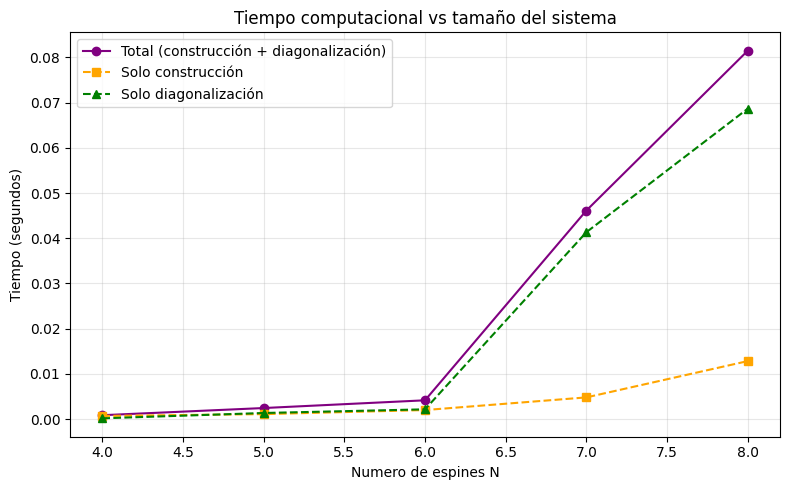

In [14]:
plt.figure(figsize=(8, 5))
plt.plot(N_list, times_total, 'o-', color='purple', label='Total (construcción + diagonalización)')
plt.plot(N_list, times_build, 's--', color='orange', label='Solo construcción')
plt.plot(N_list, times_diag, '^--', color='green', label='Solo diagonalización')
plt.xlabel('Numero de espines N')
plt.ylabel('Tiempo (segundos)')
plt.title('Tiempo computacional vs tamaño del sistema')
plt.yscale('linear')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig('timing_linear.png', dpi=150)
plt.show()

f) Estimación de la simulación

In [15]:
# Fitea log(tiempo) = a * N + b  (escalado exponencial)
log_times = np.log(times_total)
coeffs = np.polyfit(N_list, log_times, 1)   # primer grado
a, b = coeffs
print(f"Fiteo: log10(tiempo) = {a:.4f} * N + {b:.4f}")
print(f"Equivalente: time = exp({b:.4f}) * exp({a:.4f} * N)")

def estimate_time(N, a, b):
    """Return estimated time in seconds for given N."""
    return np.exp(a * N + b)

N_extrap = [20, 50, 100]
for N in N_extrap:
    t_sec = estimate_time(N, a, b)
    t_min = t_sec / 60
    t_hour = t_min / 60
    t_day = t_hour / 24
    t_year = t_day / 365.25
    print(f"\nN = {N}:")
    print(f"  Tiempo estimado = {t_sec:.2e} s")
    print(f"                ≈ {t_min:.2e} min")
    print(f"                ≈ {t_hour:.2e} h")
    print(f"                ≈ {t_day:.2e} days")
    print(f"                ≈ {t_year:.2e} years")

Fiteo: log10(tiempo) = 1.2054 * N + -12.0621
Equivalente: time = exp(-12.0621) * exp(1.2054 * N)

N = 20:
  Tiempo estimado = 1.70e+05 s
                ≈ 2.84e+03 min
                ≈ 4.73e+01 h
                ≈ 1.97e+00 days
                ≈ 5.40e-03 years

N = 50:
  Tiempo estimado = 8.64e+20 s
                ≈ 1.44e+19 min
                ≈ 2.40e+17 h
                ≈ 1.00e+16 days
                ≈ 2.74e+13 years

N = 100:
  Tiempo estimado = 1.29e+47 s
                ≈ 2.16e+45 min
                ≈ 3.59e+43 h
                ≈ 1.50e+42 days
                ≈ 4.10e+39 years


g) Comparación con la edad del universo

In [17]:
age_universe_sec = 4.3e17   # segundos
print(f"Age of the universe ≈ {age_universe_sec:.2e} s")

for N in N_extrap:
    t_sec = estimate_time(N, a, b)
    ratio = t_sec / age_universe_sec
    print(f"\nN = {N}: Tiempo estimado = {t_sec:.2e} s")
    print(f"N = {N:3d}: Tiempo estimado / edad del universo = {ratio:.2e}")

Age of the universe ≈ 4.30e+17 s

N = 20: Tiempo estimado = 1.70e+05 s
N =  20: Tiempo estimado / edad del universo = 3.96e-13

N = 50: Tiempo estimado = 8.64e+20 s
N =  50: Tiempo estimado / edad del universo = 2.01e+03

N = 100: Tiempo estimado = 1.29e+47 s
N = 100: Tiempo estimado / edad del universo = 3.01e+29
